# Regression Model For Respiratory Disease Deaths

**MATH 189 Final Project**

Group Members: Kevin Jacob, Amelia Oo, Henry Liu, Christian Kumagai

## Problem Statement

Air pollution is widely linked to respiratory health problems, but the strength of that relationship can vary across location and over time. In this project, we examine whether county-level air quality indicators are statistically associated with respiratory disease mortality in the United States. Our proposal focuses on combining environmental data with health data to explore whether patterns in air quality correspond to patterns in respiratory mortality. 

This question is relevant because air quality affects large populations and can differ significantly between counties. If certain pollution measures correspond to respiratory mortality, the relationship may highlight broader environmental health patterns. From a statistical perspective, this project also presents challenges because it requires merging datasets from different sources and evaluating how multiple pollution-related variables relate to health outcomes over time. 


## Initial Dataset

### Dataset Sources
- **CDC Wonder:** obtained yearly death counts due to respiratory illness per county
- **EPA Air Quality System:** obtained annual air quality data per county

### Processing Overview
All processing code can be found in the `data.py` file. 
- Concatenate EPA data from 2018 to 2024
- Remove rows with missing values
- Map CDC dataset county format to match EPA dataset county format
- Join datasets on State, County, and Year
- 
    Our initial dataset processing involved downloading datasets from the EPA’s Air Quality System for annual air quality data by county. As mentioned above, we are using data from 2018 through 2024. We also downloaded a dataset from CDC Wonder containing information about the counts of death due to respiratory illness as that was our health problem of interest. The dataset downloading can be seen in the data.py file which also includes some of the initial processing. The processing program starts by concatenating all the EPA datasets as we had a separate dataset for each year. It then processes any potential missing values that aren’t in the dataset by removing those rows and mapping the County format in CDC dataset to match the EPA dataset. After that, the EPA dataset is joined (State, County, and Year) with the CDC dataset and the unused columns are dropped before being saved as a csv. 

### Processed Dataset
Our initial processed dataset (before any additional variable transformations) contains the following values
- **State:** State in the US that the death count was recorded
- **County:** County in the US that the count was recorded
- **Year:** Year that the death count was recorded 
- **Days with AQI:** Total number of days in the year for which an Air Quality Index (AQI) value was reported for the county
- **Good Days:** Number of days where AQI values fell within the “Good” category (AQI 0–50)
- **Moderate Days:** Number of days where AQI values fell within the “Moderate” category (AQI 51–100)
- **Unhealthy for Sensitive Group Days:** Number of days where AQI values fell within the “Unhealthy for Sensitive Groups” category (AQI 101–150)
- **Unhealthy Days:** Number of days where AQI values fell within the “Unhealthy” category (AQI 151–200)
- **Very Unhealthy Days:** Number of days where AQI values fell within the “Very Unhealthy” category (AQI 201–300)
- **Hazardous Days:** Number of days where AQI values fell within the “Hazardous” category (AQI 301+)
- **Max AQI:** Highest AQI recorded in county for given year
- **99th Percentile AQI:** 99th percentile of recorded AQI for given county/year
- **Median AQI:** Median AQI recorded for given county/year
- **Days CO:** Number of days where carbon monoxide was primary pollutant for AQI value
- **Days NO2:** Number of days where nitrogen dioxide was primary pollutant for AQI value
- **Days Ozone:** Number of days where ozone was primary pollutant for AQI value
- **Days PM2.5:** Number of days where fine particle matter was primary pollutant for AQI value
- **Days PM10:** Number of days where coarse particle matter was primary pollutant for AQI value
- **Deaths:** Total number of deaths recorded for specific cause in county/year
- **Population:** Estimated population of county in given year
- **Crude Rate:** Death rate per 100,000 in county for given year due to cause
- **Cause:** Underlying cause of death (in our case always respiratory disease)

In [29]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sklearn import metrics
from statsmodels.tsa.stattools import acf
from utils import backward
from utils import criterion

In [30]:
# Load the cleaned dataset
df = pd.read_csv("./datasets/processed_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace(".", "_")
df["State"] = df["State"].astype('category')
df["County"] = df["County"].astype('category')

# Preview the data
df.head()

,State,County,Year,Days_with_AQI,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,...,Median_AQI,Days_CO,Days_NO2,Days_Ozone,Days_PM2_5,Days_PM10,Deaths,Population,Crude_Rate,Cause
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,...,37,0,0,194,76,0,225.0,218022.0,103.2,respiratory_diseases
1,Alabama,Clay,2018,110,86,24,0,0,0,0,...,36,0,0,0,110,0,24.0,13275.0,180.8,respiratory_diseases
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,...,37,0,0,184,93,0,97.0,54762.0,177.1,respiratory_diseases
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,...,36,0,0,286,64,0,111.0,71385.0,155.5,respiratory_diseases
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,...,33,0,0,222,0,0,93.0,81887.0,113.6,respiratory_diseases


In [31]:
# Check the variables
df.dtypes

State                                  category
County                                 category
Year                                      int64
Days_with_AQI                             int64
Good_Days                                 int64
Moderate_Days                             int64
Unhealthy_for_Sensitive_Groups_Days       int64
Unhealthy_Days                            int64
Very_Unhealthy_Days                       int64
Hazardous_Days                            int64
Max_AQI                                   int64
90th_Percentile_AQI                       int64
Median_AQI                                int64
Days_CO                                   int64
Days_NO2                                  int64
Days_Ozone                                int64
Days_PM2_5                                int64
Days_PM10                                 int64
Deaths                                  float64
Population                              float64
Crude_Rate                              

## Dataset Analysis

In [32]:
df.describe()

,Year,Days_with_AQI,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,90th_Percentile_AQI,Median_AQI,Days_CO,Days_NO2,Days_Ozone,Days_PM2_5,Days_PM10,Deaths,Population,Crude_Rate
count,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6.174000e+03,6174.000000
mean,2020.977412,329.594385,237.126008,87.907067,3.461439,0.845434,0.182156,0.072281,129.635528,60.445466,40.344789,0.178767,3.088416,161.974992,154.766538,9.585673,211.740239,2.909888e+05,100.254049
std,2.003581,67.710547,70.661562,63.380046,8.670397,3.618349,1.601665,0.706093,143.063217,15.279564,9.668227,5.172511,20.844846,114.364321,123.466126,43.834727,338.232477,5.832741e+05,40.316302
min,2018.000000,7.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,4.074000e+03,20.500000
25%,2019.000000,342.000000,199.000000,32.000000,0.000000,0.000000,0.000000,0.000000,87.000000,52.000000,36.000000,0.000000,0.000000,75.000000,5.000000,0.000000,48.000000,4.338825e+04,69.900000
50%,2021.000000,363.000000,239.000000,79.000000,1.000000,0.000000,0.000000,0.000000,106.000000,59.000000,41.000000,0.000000,0.000000,161.000000,162.000000,0.000000,109.000000,1.142910e+05,94.600000
75%,2023.000000,365.000000,290.000000,132.000000,3.000000,0.000000,0.000000,0.000000,142.000000,66.000000,45.000000,0.000000,0.000000,243.000000,251.000000,0.000000,238.000000,2.979085e+05,124.300000
max,2024.000000,366.000000,365.000000,302.000000,109.000000,69.000000,75.000000,31.000000,8368.000000,216.000000,122.000000,259.000000,365.000000,366.000000,366.000000,366.000000,5887.000000,1.010552e+07,305.400000


### Remove Columns
We can remove the `Cause` columns since all rows contain death info related to respiratory diseases as that is the focus of our project. We can also remove `Days with AQI` since the column is the sum of the different day counts meaning we have perfect multicollinearity.  `Good_Days` will also be removed due to perfect multicollinarity as the differemt day counts will add up to the number of days in a year.

In [33]:
df = df.drop(columns=["Cause", "Days_with_AQI", "Good_Days"])

### Transform Targets
Based on the column statistics above, we can see significant right skew for `Deaths` based on difference between mean and median. `Crude Rate` also shows some skew but it is less severe. We can log transform both target variables to help address the skew since having skew in our targets can skew the residuals violating the assumptions of the linear regression model.

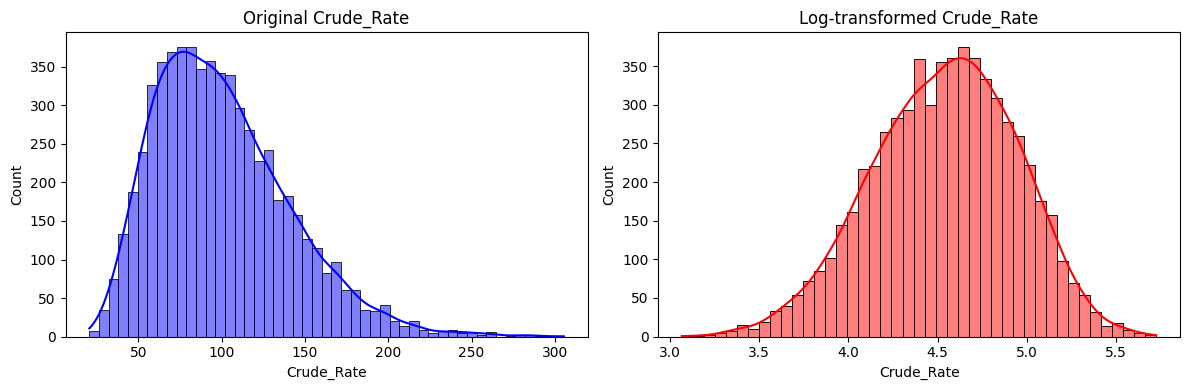

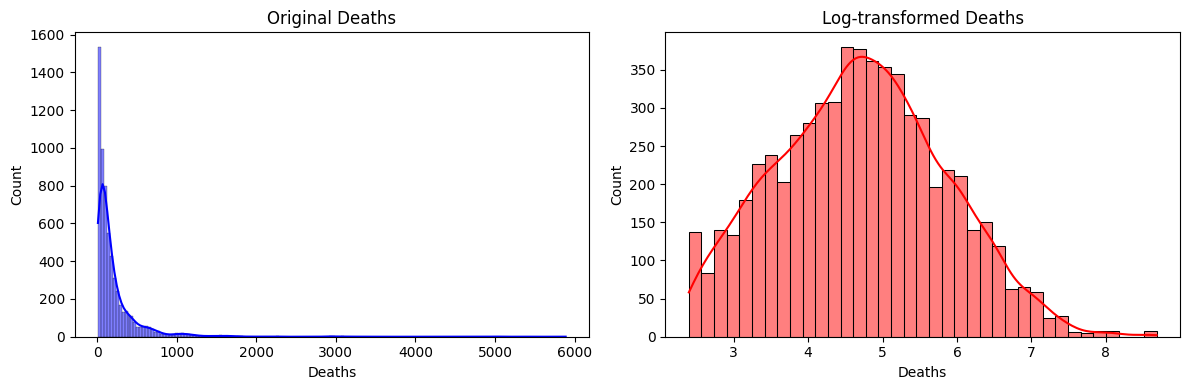

In [34]:
targets = ["Crude_Rate", "Deaths"]

for col in targets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

### Transform Features
Based on the column stats we can see that `Max AQI` and `Population` demonstrate significant right skew so we can also apply a log transformation to limit the effect of extreme values.

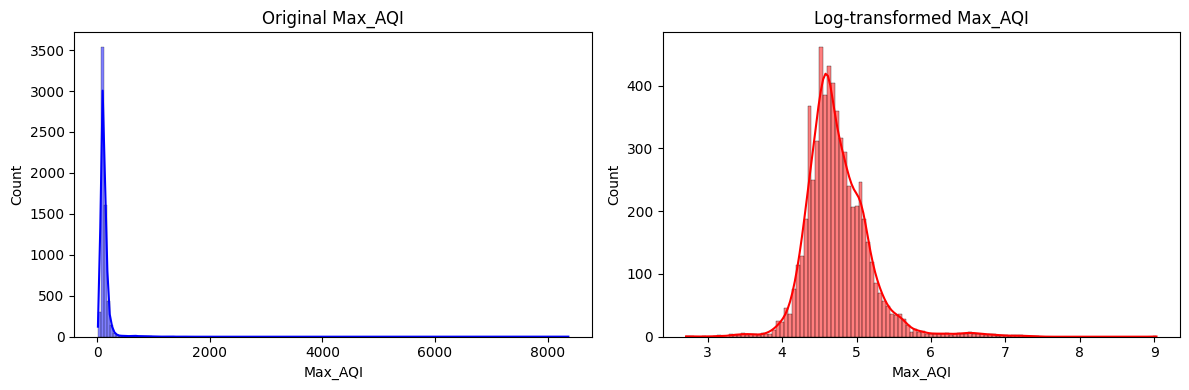

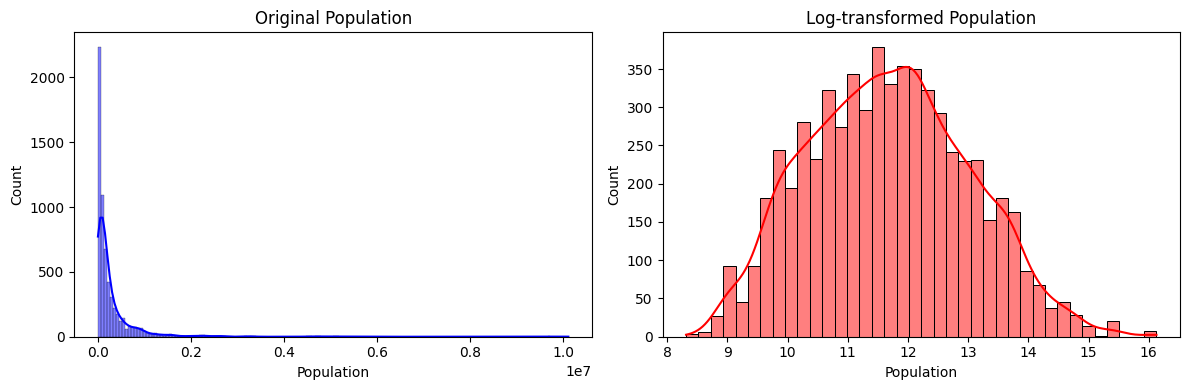

In [35]:
covariates = ["Max_AQI", "Population"]

for col in covariates:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

Based on the column stats, there appears to be significant zero inflation meaning that many of the values are 0. If we look at `Unhealthy Days`, `Very Unhealthy Days`, `Hazardous Days`, `Days CO`, `Days NO2`, and `Days PM10` they have a 75% value of 0 indicating significant zero inflation. This indicates that the events these covariates are counting are relatively rare in many places, so it would be good to add a binary value for each covariate to allow the model to have intercept shift for places that don't experience these rare events. The model can more easily handle the difference between these events never occuring or rarely occurring.

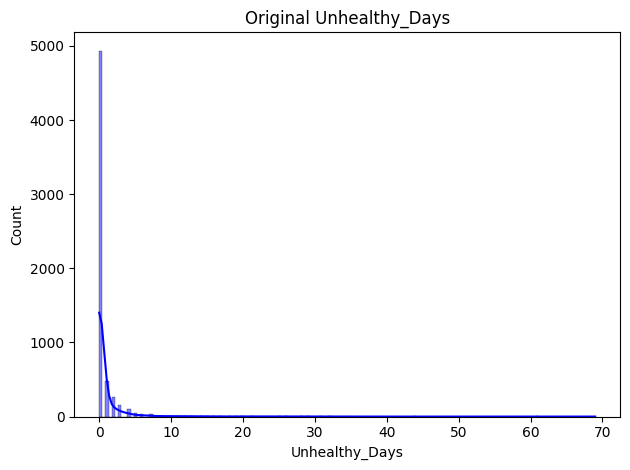

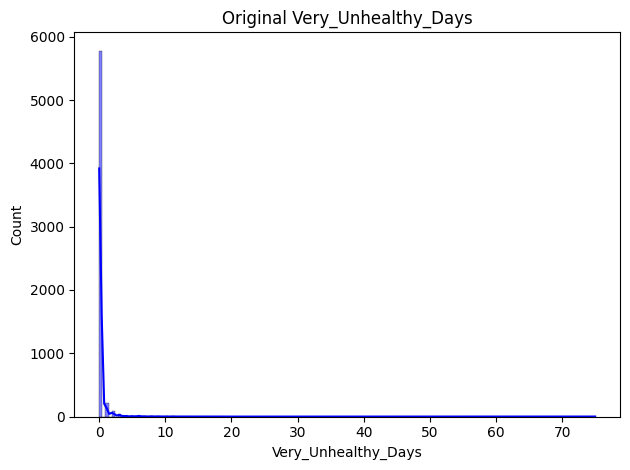

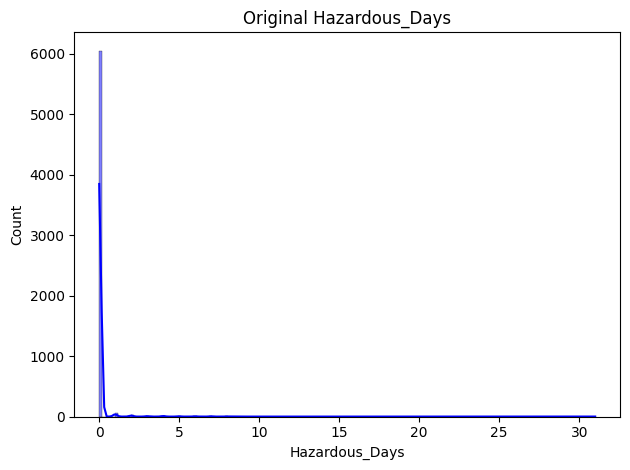

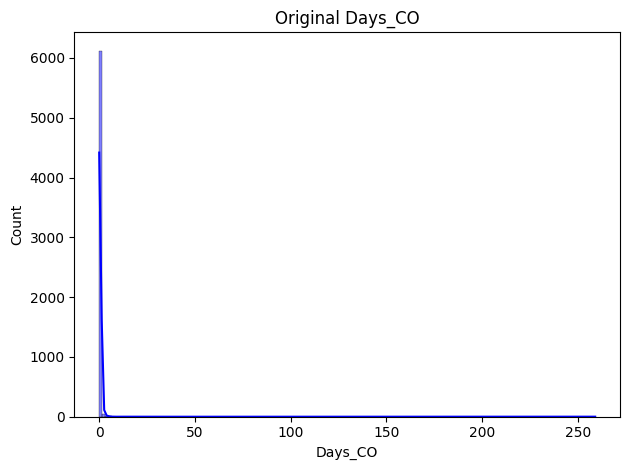

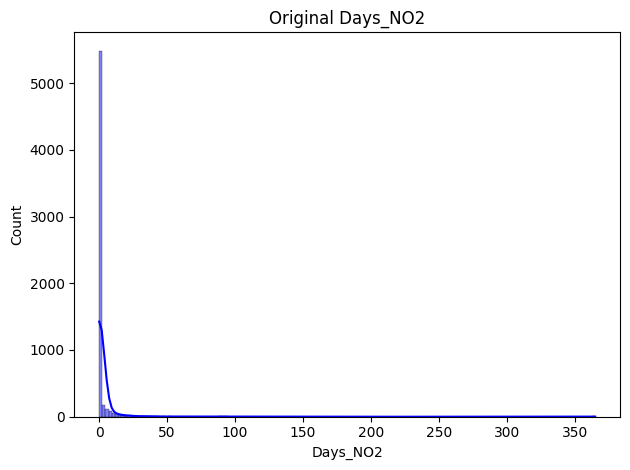

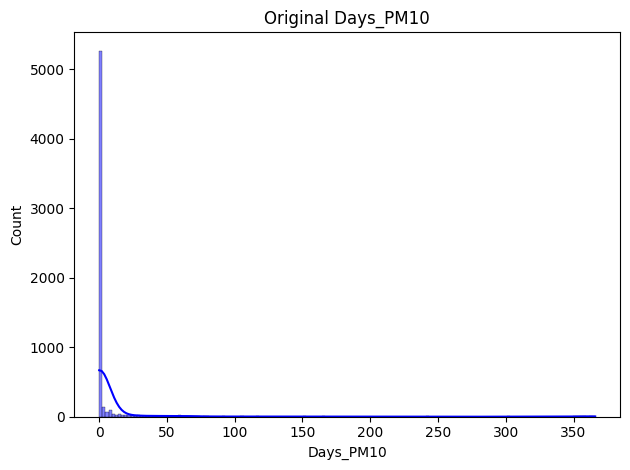

In [36]:
zero_inflated_covariates = ['Unhealthy_Days', 'Very_Unhealthy_Days', 'Hazardous_Days', 'Days_CO', 'Days_NO2', 'Days_PM10']

for col in zero_inflated_covariates:    
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f"Original {col}")
    
    plt.tight_layout()
    plt.show()

In [37]:
# Add binary terms
for col in zero_inflated_covariates:
    df[f'{col}_binary'] = (df[col] > 0).astype(int)
df.head()

,State,County,Year,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,90th_Percentile_AQI,...,Days_PM10,Deaths,Population,Crude_Rate,Unhealthy_Days_binary,Very_Unhealthy_Days_binary,Hazardous_Days_binary,Days_CO_binary,Days_NO2_binary,Days_PM10_binary
0,Alabama,Baldwin,2018,38,0,0,0,0,4.584967,54,...,0,5.420535,12.292356,4.646312,0,0,0,0,0,0
1,Alabama,Clay,2018,24,0,0,0,0,4.234107,54,...,0,3.218876,9.493713,5.202907,0,0,0,0,0,0
2,Alabama,Colbert,2018,42,0,0,0,0,4.543295,54,...,0,4.584967,10.910770,5.182345,0,0,0,0,0,0
3,Alabama,DeKalb,2018,48,0,0,0,0,4.442651,54,...,0,4.718499,11.175857,5.053056,0,0,0,0,0,0
4,Alabama,Elmore,2018,19,0,0,0,0,4.276666,49,...,0,4.543295,11.313108,4.741448,0,0,0,0,0,0


### Correlation analysis

In this part we performed correlation analysis on the numeric predictors. Categorical vairables such as `County` and `State` will be excluded.

In [38]:
corr_df = df.drop(columns=["County", "State", "Deaths", "Crude_Rate"]).dropna()
corr_matrix = corr_df.corr(numeric_only=True)

#### Correlation Matrix

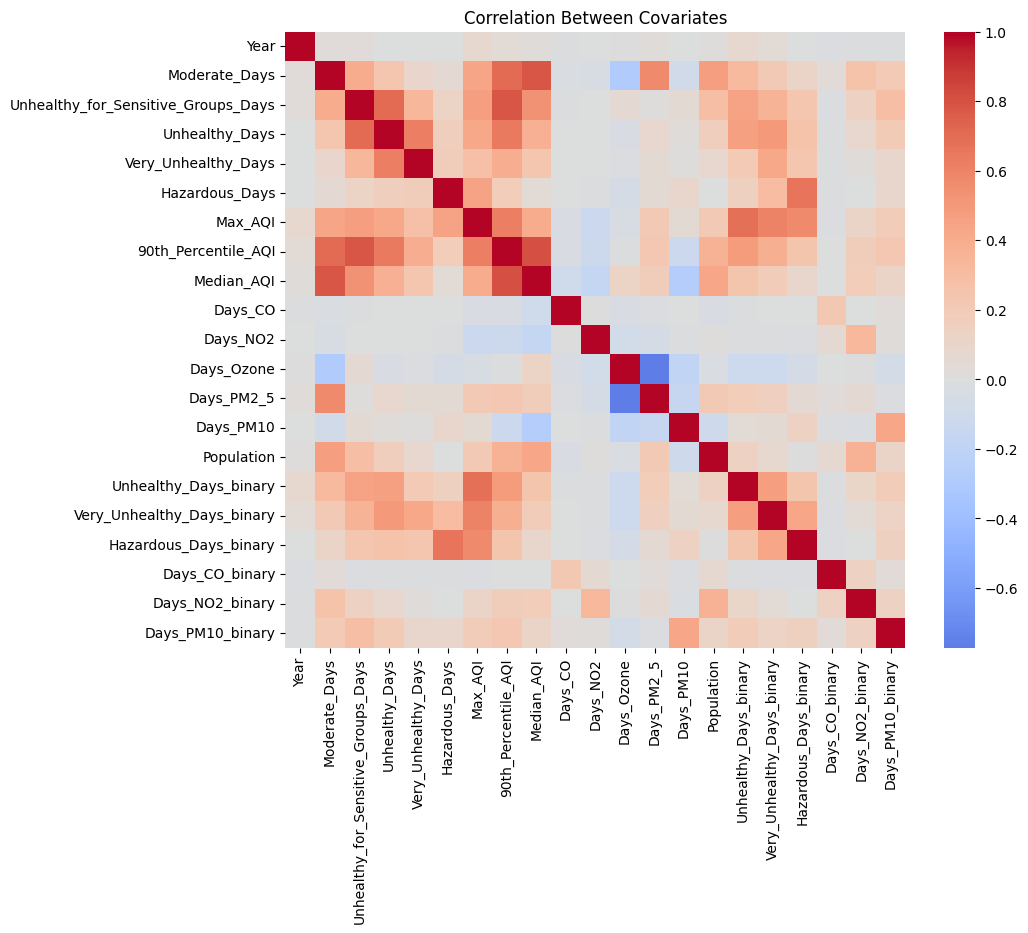

In [39]:
# Heatmap Visualization
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Covariates")
plt.show()    

The heatmap visualizes the strength and direction of correlations among the numeric variables. Warmer colors(red) suggests positive correlation, while cooler colors(blue) represent negative correlations. 

From this heatmap, we observe several strong positive correlations between the AQI-related variables including Median AQI, 90th Percentile AQI, Max AQI, and the number of Moderate, Unhealthy, and Very Unhealthy Days. This is expected because they measure similar aspects of air pollution severity.  

At the same time, the variable Good Days appears to have negative correlations with many of the pollution indicators. This makes sense because counties that experience more days with good air quality generally have fewer days with higher pollution levels.

Based on this heatmap, we have evidence of multicollinearity and should drop columns with high correlation before fitting the regression model.

#### Variance Inflation Factor

In [40]:
def calc_vifs(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["variable"] = df_const.columns
    vif["VIF"] = [variance_inflation_factor(df_const.values, i) 
                  for i in range(df_const.shape[1])]
    return vif.set_index("variable").drop("const")

In [41]:
calc_vifs(corr_df)

,VIF
variable,
Year,1.015784
Moderate_Days,9.431085
Unhealthy_for_Sensitive_Groups_Days,3.959984
Unhealthy_Days,3.753254
Very_Unhealthy_Days,1.889127
Hazardous_Days,1.873041
Max_AQI,4.539715
90th_Percentile_AQI,9.191586
Median_AQI,7.346519


If we look at the VIF values, most of them appear to be really high with inf values indicating severe multicollinarity as suggested by the covariance matrix. We can remove inf values one by one where we chose to remove the inf value with the lowest correlation to our target values.

In [42]:
remaining = corr_df.columns.tolist()
iteration = 1

while True:
    vif_df = calc_vifs(df[remaining].dropna()).sort_values("VIF", ascending=False)
    print(f"\nIteration {iteration}")
    print(vif_df.round(2).to_string())

    has_inf  = np.isinf(vif_df["VIF"]).any()
    max_vif  = vif_df["VIF"].replace(np.inf, np.nan).max()

    if max_vif < 5:
        print("\nDone.")
        break
    
    worst = vif_df["VIF"].idxmax()

    print(f"\nDropping: '{worst}'")
    remaining.remove(worst)
    iteration += 1


Iteration 1
                                      VIF
variable                                 
Moderate_Days                        9.43
90th_Percentile_AQI                  9.19
Median_AQI                           7.35
Days_PM2_5                           6.78
Max_AQI                              4.54
Days_Ozone                           4.26
Unhealthy_for_Sensitive_Groups_Days  3.96
Unhealthy_Days                       3.75
Hazardous_Days_binary                2.40
Unhealthy_Days_binary                2.38
Days_PM10                            2.24
Very_Unhealthy_Days_binary           1.94
Very_Unhealthy_Days                  1.89
Hazardous_Days                       1.87
Population                           1.47
Days_PM10_binary                     1.45
Days_NO2                             1.43
Days_NO2_binary                      1.39
Days_CO                              1.11
Days_CO_binary                       1.08
Year                                 1.02

Dropping: 'Moderate_

With the reduced set of covariates, we can see that we now have a set of covariates with a resonable VIF value.

In [43]:
calc_vifs(df[remaining].dropna())

,VIF
variable,
Year,1.014753
Unhealthy_for_Sensitive_Groups_Days,2.866765
Unhealthy_Days,3.330501
Very_Unhealthy_Days,1.817844
Hazardous_Days,1.854679
Max_AQI,4.062881
Median_AQI,2.154077
Days_CO,1.078578
Days_NO2,1.301916


After removing variables with high multicollinearity, the remaining covariates represent different aspects of air quality conditions and demographic factors. Variables such as Moderate_Days, Unhealthy_Days, Very_Unhealthy_Days, Hazardous_Days, and Max_AQI describe the severity of air pollution across counties. 

Additional variables including Days_CO, Days_Ozone, and Days_PM10 capture pollution from specific pollutants. Binary indicators (e.g., Unhealthy_Days_binary, Very_Unhealthy_Days_binary, Days_NO2_binary) indicate whether these pollution events occurred at least once in a given year. Finally, Population controls for differences in county size and Year accounts for overall time trends.

## Fitting Regression Model

### Processed Dataset
Split the dataset into a train set and test set for evaluating the model later

In [44]:
in_features = remaining
df = df[in_features + ["Deaths","Crude_Rate"]].dropna()
df.head()

,Year,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,Median_AQI,Days_CO,Days_NO2,Days_Ozone,...,Days_PM10,Population,Unhealthy_Days_binary,Very_Unhealthy_Days_binary,Hazardous_Days_binary,Days_CO_binary,Days_NO2_binary,Days_PM10_binary,Deaths,Crude_Rate
0,2018,0,0,0,0,4.584967,37,0,0,194,...,0,12.292356,0,0,0,0,0,0,5.420535,4.646312
1,2018,0,0,0,0,4.234107,36,0,0,0,...,0,9.493713,0,0,0,0,0,0,3.218876,5.202907
2,2018,0,0,0,0,4.543295,37,0,0,184,...,0,10.910770,0,0,0,0,0,0,4.584967,5.182345
3,2018,0,0,0,0,4.442651,36,0,0,286,...,0,11.175857,0,0,0,0,0,0,4.718499,5.053056
4,2018,0,0,0,0,4.276666,33,0,0,222,...,0,11.313108,0,0,0,0,0,0,4.543295,4.741448


In [45]:
def split_data_by_year(group_df, train_frac=0.8, random_state=42):
    train_set = group_df.sample(frac=train_frac, random_state=random_state)
    test_set = group_df.drop(train_set.index)
    return train_set, test_set

train_list = []
test_list = []

for year, group_df in df.groupby('Year'):
    train_subset, test_subset = split_data_by_year(group_df, train_frac=0.8, random_state=42)
    train_list.append(train_subset)
    test_list.append(test_subset)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print(f"Train Set Size: {len(train_df)}")
print(f"Test Set Size: {len(test_df)}")

Train Set Size: 4939
Test Set Size: 1235


In [46]:
def generate_formulas(response, input_variables):
    formulas = []
    for k in range(1, len(in_features) + 1):
        for combo in combinations(input_variables, k):
            formula = response + "~" + " + ".join(combo)
            formulas.append(formula)
    return formulas

def find_best_bic(formulas):
    best_bic = np.inf
    best_formula = None 
    for formula in tqdm(formulas):
        model = smf.ols(formula=formula, data=train_df).fit()
        if model.bic < best_bic:
            best_bic = model.bic
            best_formula = formula
    return best_formula

### Mutliple Linear Regeression Model For Deaths

#### Backward Selection With BIC Criterion

In [64]:
train_death_df = train_df.drop(columns=["Crude_Rate"])
selected_covariates = backward(train_death_df, criterion, response = 'Deaths')
selected_model = 'Deaths' + ' ~ ' + " + ".join(selected_covariates)
print(f"Selected Model: {selected_model}")

Criterion: 2644.484045487279
Criterion: 2642.4934079855357
Criterion: 2640.5688426737233
Criterion: 2638.912621750351
Criterion: 2637.4524444364397
Criterion: 2636.6737133232145
Selected Model: Deaths ~ Unhealthy_for_Sensitive_Groups_Days + Max_AQI + Population + Unhealthy_Days + Unhealthy_Days_binary + Days_CO + Year + Very_Unhealthy_Days_binary + Hazardous_Days_binary + Days_NO2 + Days_PM10 + Days_NO2_binary + Median_AQI


In [65]:
death_model = smf.ols(formula=selected_model, data=train_df).fit()
death_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     4413.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:17:08   Log-Likelihood:                -1304.3
No. Observations:                4939   AIC:                             2637.
Df Residuals:                    4925   BIC:                             2728.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              21.1998      4.557      4.652      0.000      12.267      30.133
Unhealthy_for_Sensitive_Groups_Days    -0.0034      0.001     -3.723      0.000      -0.005      -0.002
Max_AQI                                -0.1277      0.020     -6.389      0.000      -0.167      -0.089
Population                              0.8157      0.004    205.876      0.000       0.808       0.823
Unhealthy_Days                          0.0036      0.002      1.826      0.068      -0.000       0.008
Unhealthy_Days_binary                  -0.0359      0.017     -2.149      0.032      -0.069      -0.003
Days_CO                                 0.0027      0.001      2.187      0.029       0.000       0.005
Year                                   -0.0127      0.002     -5.625      0.000      -0.017      -0.008
Very_Unhealthy_Days_binary              0.0805      0.025      3.272      0.001       0.032       0.129
Hazardous_Days_binary                   0.0711      0.039      1.826      0.068      -0.005       0.147
Days_NO2                               -0.0005      0.000     -2.010      0.044      -0.001   -1.17e-05
Days_PM10                               0.0005      0.000      4.292      0.000       0.000       0.001
Days_NO2_binary                        -0.1038      0.014     -7.401      0.000      -0.131      -0.076
Median_AQI                              0.0065      0.001      9.820      0.000       0.005       0.008
==============================================================================
Omnibus:                      244.135   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              289.481
Skew:                          -0.535   Prob(JB):                     1.38e-63
Kurtosis:                       3.513   Cond. No.                     2.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [49]:
restored_formula = "Deaths ~ Max_AQI + Days_PM2_5 + Population + Year + Days_NO2_binary + Days_PM10 + Very_Unhealthy_Days_binary"
death_model = smf.ols(formula=restored_formula, data=train_df).fit()
death_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     7973.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:16:08   Log-Likelihood:                -1370.0
No. Observations:                4939   AIC:                             2756.
Df Residuals:                    4931   BIC:                             2808.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     23.4785      4.601      5.103      0.000      14.458      32.499
Max_AQI                       -0.0963      0.014     -7.046      0.000      -0.123      -0.069
Days_PM2_5                  5.955e-05   3.89e-05      1.531      0.126   -1.67e-05       0.000
Population                     0.8261      0.004    216.602      0.000       0.819       0.834
Year                          -0.0138      0.002     -6.072      0.000      -0.018      -0.009
Days_NO2_binary               -0.1127      0.013     -8.534      0.000      -0.139      -0.087
Days_PM10                      0.0001      0.000      1.369      0.171   -6.36e-05       0.000
Very_Unhealthy_Days_binary     0.0663      0.023      2.882      0.004       0.021       0.111
==============================================================================
Omnibus:                      236.175   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              276.540
Skew:                          -0.530   Prob(JB):                     8.91e-61
Kurtosis:                       3.468   Cond. No.                     2.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Interpretation of Regression Results

The regression results indicate that several air quality variables are statistically associated with respiratory disease deaths. *Moderate_Days* has a positive coefficient, suggesting that areas with more days of moderate air pollution tend to experience higher respiratory death counts. The indicator for *Very_Unhealthy_Days_binary* is also positively associated with deaths, indicating that the presence of more severe pollution events may be linked to worse respiratory health outcomes.

However, while *Moderate_Days* and *Very_Unhealthy_Days_binary* have positive coefficients, *Unhealthy_Days_binary* has a negative coefficient. This contrast likely reflects correlations among the air quality indicators, where the coefficient represents the association of Unhealthy_Days with deaths after controlling for the other pollution variables in the model.

On the other hand, *Year* shows a negative coefficient, suggesting a slight decreasing trend in respiratory deaths over time in the dataset. *Population* is strongly positively associated with deaths, which is expected since areas with larger populations generally experience more total deaths.

Overall, the model demonstrates strong explanatory power with an R² of 0.92. This means that approximately 92% of the variation in respiratory disease deaths is explained by the predictors included in the model.
The F-statistic is highly significant (p < 0.001), indicating that the model as a whole provides a statistically meaningful explanation of the response variable.

#### Validate Model Assumptions

In [50]:
residuals = death_model.resid

**Normality**

Residuals are approximately normally distributed with minor deviation in the tails, particularly at the lower extreme likely driven by counties with very low death counts. Based on the mild deviation from the line, our model doesn't materially violate the normality assumption.

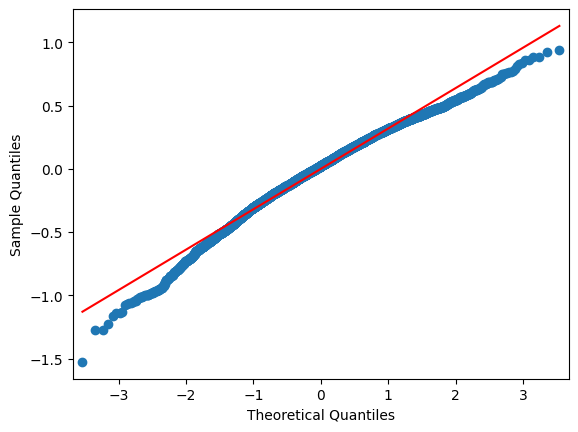

In [51]:
sm.qqplot(residuals, line='s')
plt.show()

**Independence**

Based on the ACF graph, the bars after lag 0 appear to be close to 0 indicating the independence assumption being satisfied.

(-0.1, 1.1)

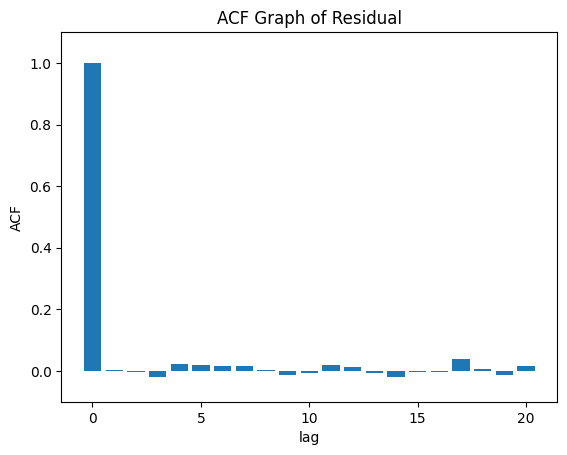

In [52]:
lags = 20
plt.bar(range(lags+1), acf(residuals, nlags=lags))
plt.title("ACF Graph of Residual")
plt.xlabel('lag')
plt.ylabel('ACF')
plt.ylim((-0.1, 1.1))

**Heteroscedasticity**

Based on the scatterplot of standardized residuals vs. fitted values, we see that there is a lot of scattered points around 0 indicating that the heteroscedasticity assumption is satisfied. We also see that the scatter plot is random indicating the linearity assumption being satisfied.

Text(0.5, 0, 'Fitted Values')

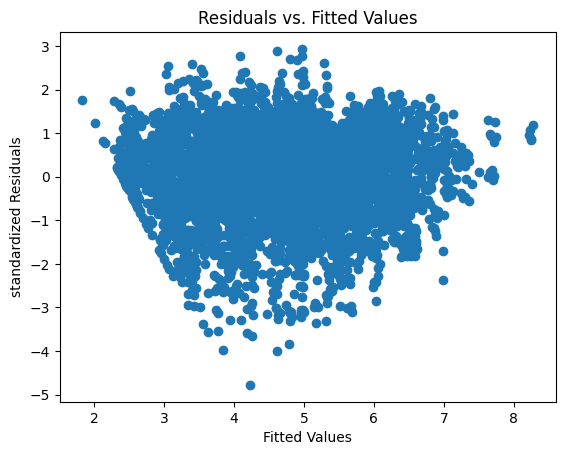

In [53]:
def standardize(X):
    return (X - X.mean()) / X.std()

plt.scatter(death_model.fittedvalues, standardize(residuals))
plt.title("Residuals vs. Fitted Values")
plt.ylabel("standardized Residuals")
plt.xlabel("Fitted Values")

#### Test Accuracy On Test Set

These are the log scaled metrics as the targets have been log scaled

In [54]:
def validate_model(model,test_df,target):
    targets = test_df[target]
    preds = model.predict(exog=test_df)
    mae = metrics.mean_absolute_error(targets, preds)
    mse = metrics.mean_squared_error(targets, preds)
    rmse = np.sqrt(mse) 
    r_squared = metrics.r2_score(targets, preds)
    print(f"Test Set MAE: {mae:.2f}")
    print(f"Test Set RMSE: {rmse:.2f}")
    print(f"Test Set R-squared: {r_squared:.2f}")

In [55]:
validate_model(death_model,test_df,"Deaths")

Test Set MAE: 0.25
Test Set RMSE: 0.32
Test Set R-squared: 0.92


#### Model Performance on Test Data
To evaluate the predictive performance of the regression model, we applied it to the test dataset. Because the response variables were log-transformed, the reported error metrics are also in the log scale. The model achieved a test MAE of 0.25 and a test RMSE of 0.32, indicating relatively small prediction errors.

In addition, the model obtained a test $R^2$ of 0.92, suggesting that it explains approximately 92% of the variation in respiratory disease deaths in the test data.

These results indicate that the model maintains strong predictive performance on unseen data, suggesting that the selected predictors generalize well beyond the training dataset.

### Mutliple Linear Regeression Model For Crude Rate

#### Backward Selection With BIC Criterion

In [56]:
train_crude_df = train_df.drop(columns=["Deaths"])
selected_covariates = backward(train_crude_df, criterion, response = 'Crude_Rate')
selected_model = 'Deaths ' + '~' + " + ".join(selected_covariates)
print(f"Selected Model: {selected_model}")

Criterion: 2680.929820291445
Criterion: 2678.9322886820664
Criterion: 2676.9827982277693
Criterion: 2675.3285294516154
Criterion: 2673.858503986139
Criterion: 2672.893239278652
Selected Model: Deaths ~Unhealthy_for_Sensitive_Groups_Days + Max_AQI + Population + Unhealthy_Days + Unhealthy_Days_binary + Days_CO + Year + Very_Unhealthy_Days_binary + Hazardous_Days_binary + Days_NO2 + Days_PM10 + Days_NO2_binary + Median_AQI


In [57]:
crude_model = smf.ols(formula=selected_model, data=train_df).fit()
crude_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     4413.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:16:10   Log-Likelihood:                -1304.3
No. Observations:                4939   AIC:                             2637.
Df Residuals:                    4925   BIC:                             2728.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              21.1998      4.557      4.652      0.000      12.267      30.133
Unhealthy_for_Sensitive_Groups_Days    -0.0034      0.001     -3.723      0.000      -0.005      -0.002
Max_AQI                                -0.1277      0.020     -6.389      0.000      -0.167      -0.089
Population                              0.8157      0.004    205.876      0.000       0.808       0.823
Unhealthy_Days                          0.0036      0.002      1.826      0.068      -0.000       0.008
Unhealthy_Days_binary                  -0.0359      0.017     -2.149      0.032      -0.069      -0.003
Days_CO                                 0.0027      0.001      2.187      0.029       0.000       0.005
Year                                   -0.0127      0.002     -5.625      0.000      -0.017      -0.008
Very_Unhealthy_Days_binary              0.0805      0.025      3.272      0.001       0.032       0.129
Hazardous_Days_binary                   0.0711      0.039      1.826      0.068      -0.005       0.147
Days_NO2                               -0.0005      0.000     -2.010      0.044      -0.001   -1.17e-05
Days_PM10                               0.0005      0.000      4.292      0.000       0.000       0.001
Days_NO2_binary                        -0.1038      0.014     -7.401      0.000      -0.131      -0.076
Median_AQI                              0.0065      0.001      9.820      0.000       0.005       0.008
==============================================================================
Omnibus:                      244.135   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              289.481
Skew:                          -0.535   Prob(JB):                     1.38e-63
Kurtosis:                       3.513   Cond. No.                     2.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Interpretation of Regression Results 

The results for the crude rate model are largely consistent with those observed in the death model. Variables such as *Moderate_Days* and *Very_Unhealthy_Days_binary* remain positively associated with respiratory mortality, suggesting that higher levels of air pollution are linked to worse respiratory health outcomes. Similarly, *Year* continues to show a negative coefficient, indicating a slight decreasing trend in respiratory mortality over time.

One notable difference is the coefficient for *Population*, which is negative in this model. This is expected because the crude rate measures deaths relative to population size, meaning that areas with larger populations may have lower mortality rates when deaths are normalized by population.

Overall, the model explains a moderate portion of the variation in crude rate, with an R² of 0.372. The F-statistic remains highly significant (p < 0.001), indicating that the predictors collectively provide a statistically meaningful explanation of the variation in the response variable.

#### Validate Model Assumptions

In [58]:
residuals = crude_model.resid

**Normality**

Residuals are approximately normally distributed with minor deviation in the tails, particularly at the lower extreme likely driven by counties with very low death counts. Based on the mild deviation from the line, our model doesn't materially violate the normality assumption.

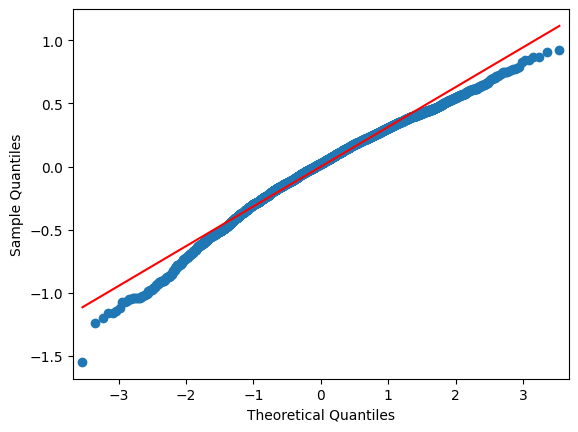

In [59]:
sm.qqplot(residuals, line='s')
plt.show()

**Independence**

Based on the ACF graph, the bars after lag 0 appear to be close to 0 indicating the independence assumption being satisfied.

(-0.1, 1.1)

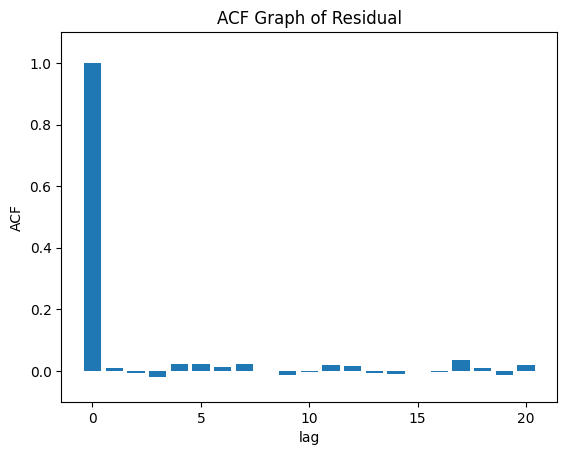

In [60]:
lags = 20
plt.bar(range(lags+1), acf(residuals, nlags=lags))
plt.title("ACF Graph of Residual")
plt.xlabel('lag')
plt.ylabel('ACF')
plt.ylim((-0.1, 1.1))

**Heteroscedasticity**

Based on the scatterplot of standardized residuals vs. fitted values, we see that there is a lot of scattered points around 0 indicating that the heteroscedasticity assumption is satisfied. We also see that the scatter plot is random indicating the linearity assumption being satisfied.

Text(0.5, 0, 'Fitted Values')

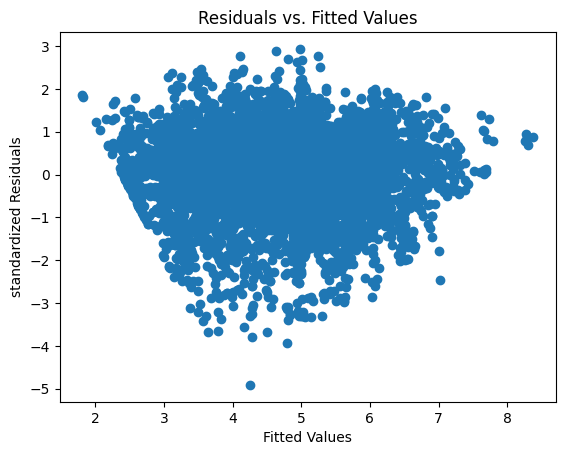

In [61]:
plt.scatter(crude_model.fittedvalues, standardize(residuals))
plt.title("Residuals vs. Fitted Values")
plt.ylabel("standardized Residuals")
plt.xlabel("Fitted Values")

#### Test Accuracy On Test Set

These are the log scaled metrics as the targets have been log scaled

In [62]:
def validate_model(model,test_df,target):
    targets = test_df[target]
    preds = model.predict(exog=test_df)
    mae = metrics.mean_absolute_error(targets, preds)
    mse = metrics.mean_squared_error(targets, preds)
    rmse = np.sqrt(mse) 
    r_squared = metrics.r2_score(targets, preds)
    print(f"Test Set MAE: {mae:.2f}")
    print(f"Test Set RMSE: {rmse:.2f}")
    print(f"Test Set R-squared: {r_squared:.2f}")

In [63]:
validate_model(crude_model,test_df,"Crude_Rate")

Test Set MAE: 1.16
Test Set RMSE: 1.42
Test Set R-squared: -10.86


##### Model Performance on Test Data
To evaluate the predictive performance of the model, we applied it to the test dataset. The model achieved a test MAE of 0.25 and a test RMSE of 0.32 (on the log-transformed scale), indicating that the prediction errors are relatively small on average. The test $R^2$ is 0.39, meaning that the model explains about 39% of the variation in Crude rate in the test data.

Although the $R^2$ is lower than that of the Deaths model, this is expected because crude rate represents deaths relative to population size, which removes much of the variation explained by population. Additionally, crude rate may depend on other factors not included in the model, so the predictors capture only part of the variation in the response variable.

## Project Limitations

- The dataset does not include information about local environmental policies (e.g., emission regulations), so some confounding factors affecting air quality and respiratory mortality may not be captured in the models.

- The analysis covers a relatively short time period, which may limit the ability to observe long-term environmental and health trends.

- Since the data only includes counties in the United States, the findings may not generalize to other regions with different environmental conditions.

- The year 2020 may introduce irregularities due to the COVID-19 pandemic, which could have affected both air pollution levels and mortality reporting.

## Related Work

PUT RELATED WORK INFO HERE

## Summary

-  Our analysis suggests that poorer air quality conditions are associated with higher levels of respiratory disease deaths.

- Several air quality indicators show measurable statistical relationships with respiratory health outcomes, suggesting that environmental conditions play a role in explaining differences across regions.

- However, the strength of these relationships varies and may also be influenced by other factors such as healthcare access, demographics, and local environmental policies.

- Overall, the findings highlight the potential role of air quality conditions in shaping respiratory health outcomes and demonstrate how statistical analysis can be used to study environmental health patterns.